In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
import torch
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage
from nltk.stem import PorterStemmer
from rapidfuzz import fuzz
import warnings
import os
warnings.filterwarnings('ignore')

In [ ]:
print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

PyTorch version: 2.10.0
MPS available: True


In [ ]:
import subprocess
result = subprocess.run(['find', '/Users/Muizzdev', '-name', '*.csv', '-not', '-path', '*/.*'],
                      capture_output=True, text=True)
print(result.stdout)

/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-log2.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-arcsinh.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-arctanh.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-sin.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-cos.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-cbrt.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-arctan.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/data/umath-validation-set-cosh.csv
/Users/Muizzdev/Library/Python/3.11/lib/python/site-packages/numpy/_core/tests/dat

In [ ]:
print(os.getcwd())

/Users/Muizzdev/hackathon


# Data preparation

In [ ]:
df = pd.read_csv("/Users/Muizzdev/hackathon/hackathon_2.csv", encoding='utf-8-sig')


In [ ]:
df.shape

(235, 5)

In [ ]:
df.head()

,accession_id,performance_date,act_name,act_description,source_file
0,178R12,"EASTER MONDAY, APRIL 3rd, 1893",Mr. ARTHUR LLOYD,THE GREAT VOCAL COMEDIAN.\nThe name of Arthur ...,NFA178R12-38.jpg
1,178R12,"EASTER MONDAY, APRIL 3rd, 1893",HOLMES,"The Great Continental Wonders, for Six Nights ...",NFA178R12-38.jpg
2,178R12,"EASTER MONDAY, APRIL 3rd, 1893",MISS MARION LENA,In their Bewildering Performance both Novel an...,NFA178R12-38.jpg
3,178R12,"EASTER MONDAY, APRIL 3rd, 1893",PRINCE,Character Comic Vocalist.-Hear his Great Footb...,NFA178R12-38.jpg
4,178R12,"EASTER MONDAY, APRIL 3rd, 1893",SAWYER & ELLIS,"Eccentric Knookabout Comedians, Vocalists and ...",NFA178R12-38.jpg


In [ ]:
print(len(df))

235


In [ ]:
print(f'Unique act descriptions: {df["act_description"].nunique()}')

Unique act descriptions: 226


In [ ]:
print(f'Missing act_description: {df["act_description"].isna().sum()}')
print(f'Empty act_description: {(df["act_description"].fillna("").str.strip() == "").sum()}')


Missing act_description: 1
Empty act_description: 1


In [ ]:
df['poster_id'] = df['source_file'].apply(
    lambda x: x.replace('NFA', '').replace('-', '.').replace('.jpg', '')
)
print(f'\nUnique posters: {df["poster_id"].nunique()}')


Unique posters: 24


# Data Preprocessing

In [ ]:
stemmer = PorterStemmer()

In [ ]:
df['act_description'] = df['act_description'].fillna('').str.strip()

# Tracking empty descriptions
empty_mask = df['act_description'] == ''
print(f'Rows with empty act descriptions (will be labelled "Unknown"): {empty_mask.sum()}')

# Working only with non-empty descriptions

df_valid = df[~empty_mask].copy().reset_index(drop=True)
print(f'Rows to classify: {len(df_valid)}')

def clean_description(text):

    # Replace newlines with spaces
    text = text.replace('\n', ' ')

    # Remove common phrases (noise)
    noise_phrases = [
        r'for (one|six|this) week(s)? only[,.]?',
        r'(first|last|return) (appearance|engagement|six nights)[\w\s]*[,.]',
        r'engagement[\w\s]*of[\w\s]*[,.]',
        r'special engagement[\w\s]*[,.]',
        r'in (conjunction|his|her|their)[\w\s]*[,.]',
        r'will appear[\w\s]*[,.]',
        r'(mr|mrs|miss|messrs|mons|professor|prof)\.?\s+\w+',
        r'the (celebrated|renowned|popular|great|favourite|favorite)\s+',
        r'(enormous|wonderful|successful|beautiful|brilliant)\s+',
        r'return to his native[\w\s]*[,.]',
        r'"[^"]*"',  # remove quoted show titles
        r'\"\"[^\"]*\"\"',  # remove double-quoted titles
    ]

    clean = text
    for pattern in noise_phrases:
        clean = re.sub(pattern, ' ', clean, flags=re.IGNORECASE)

    # Clean up whitespace
    clean = re.sub(r'\s+', ' ', clean).strip()
    clean = clean.strip('.,;:- ')

    return clean

def preprocess(text):
    """Lowercase, remove punctuation, stem words."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    words = text.split()
    words = [stemmer.stem(w) for w in words]
    return ' '.join(words)




Rows with empty act descriptions (will be labelled "Unknown"): 1
Rows to classify: 234


applying preprocessing and cleaning to the texts

In [ ]:
df_valid['act_cleaned'] = df_valid['act_description'].apply(clean_description)
df_valid['act_processed'] = df_valid['act_cleaned'].apply(preprocess)

In [ ]:
print('Stemming examples:')
for i in range(8):
    print(f'before: {df_valid["act_description"].iloc[i]}')
    print(f'after:  {df_valid["act_cleaned"].iloc[i]}')
    print()

Stemming examples:
before: THE GREAT VOCAL COMEDIAN.
The name of Arthur Lloyd is known in every English-speaking country
in the world; he is the Author of upwards of 1,000 Humorous Songs and
the Great Irish Drama, "Ballyvogan."
after:  VOCAL COMEDIAN. The name of Arthur Lloyd is known in every English-speaking country in the world; he is the Author of upwards of 1,000 Humorous Songs and Irish Drama

before: The Great Continental Wonders, for Six Nights only, Professor ALF.
after:  Continental Wonders, for Six Nights only

before: In their Bewildering Performance both Novel and Amusing.
For Six Nights only, Mr. GEORGE
after:  For Six Nights only

before: Character Comic Vocalist.-Hear his Great Football Song.
Engagement, for this Week, of the Renowned Messrs.
after:  Character Comic Vocalist.-Hear his Great Football Song. Engagement, for this Week, of Messrs

before: Eccentric Knookabout Comedians, Vocalists and Dancers.
For One Week only, Mons.
after:  Eccentric Knookabout Comedians, V

In [ ]:
print('Preprocessing examples:')
for i in range(5):
    print(f'before: {df_valid["act_description"].iloc[i]}')
    print(f'after:  {df_valid["act_cleaned"].iloc[i]}')
    print()

Preprocessing examples:
before: THE GREAT VOCAL COMEDIAN.
The name of Arthur Lloyd is known in every English-speaking country
in the world; he is the Author of upwards of 1,000 Humorous Songs and
the Great Irish Drama, "Ballyvogan."
after:  VOCAL COMEDIAN. The name of Arthur Lloyd is known in every English-speaking country in the world; he is the Author of upwards of 1,000 Humorous Songs and Irish Drama

before: The Great Continental Wonders, for Six Nights only, Professor ALF.
after:  Continental Wonders, for Six Nights only

before: In their Bewildering Performance both Novel and Amusing.
For Six Nights only, Mr. GEORGE
after:  For Six Nights only

before: Character Comic Vocalist.-Hear his Great Football Song.
Engagement, for this Week, of the Renowned Messrs.
after:  Character Comic Vocalist.-Hear his Great Football Song. Engagement, for this Week, of Messrs

before: Eccentric Knookabout Comedians, Vocalists and Dancers.
For One Week only, Mons.
after:  Eccentric Knookabout Comedia

In [ ]:
print(f'Missing act_description: {df["act_description"].isna().sum()}')

Missing act_description: 0


# TF IDF Vectorisation (SKIP)

In [ ]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),     # unigrams and bigrams
    max_features=500,       # cap features to avoid noise
    min_df=2,               # term must appear in at least 2 docs
    stop_words='english'    # remove common English stopwords
)

In [ ]:
tfidf_matrix = tfidf.fit_transform(df_valid['act_clean'])
feature_names = tfidf.get_feature_names_out()

KeyError: 'act_clean'

In [ ]:
print(f'TF-IDF matrix shape: {tfidf_matrix.shape}')
print(f'Number of features (terms): {len(feature_names)}')


TF-IDF matrix shape: (260, 129)
Number of features (terms): 129


In [ ]:
print(f'top 30 terms by TF-IDF sum:')
term_freq = np.asarray(tfidf_matrix.sum(axis=0)).flatten()
top_indices = term_freq.argsort()[::-1][:30]
for idx in top_indices:
    print(f'  {feature_names[idx]:30s}  (TF-IDF sum: {term_freq[idx]:.2f})')

top 30 terms by TF-IDF sum:
  comedian                        (TF-IDF sum: 24.40)
  vocalist                        (TF-IDF sum: 21.60)
  dancer                          (TF-IDF sum: 15.65)
  act                             (TF-IDF sum: 14.82)
  comic                           (TF-IDF sum: 10.16)
  comedi                          (TF-IDF sum: 9.89)
  singer                          (TF-IDF sum: 9.47)
  vocalist dancer                 (TF-IDF sum: 9.11)
  charact                         (TF-IDF sum: 8.35)
  artist                          (TF-IDF sum: 8.17)
  vocal                           (TF-IDF sum: 7.91)
  comedienn                       (TF-IDF sum: 7.63)
  comic vocalist                  (TF-IDF sum: 7.38)
  serio                           (TF-IDF sum: 6.99)
  entertain                       (TF-IDF sum: 6.32)
  pictur                          (TF-IDF sum: 6.32)
  burlesqu                        (TF-IDF sum: 6.01)
  music                           (TF-IDF sum: 5.58)
  song       

Finding optimal number of K using elbow and silhouette

In [ ]:
K_range = range(3, 16)
inertias = []
silhouette_scores_list = []

In [ ]:
for k in K_range:
    km = KMeans(n_clusters=k, random_state=1234, n_init=10)
    labels = km.fit_predict(tfidf_matrix)
    inertias.append(km.inertia_)
    sil = silhouette_score(tfidf_matrix, labels)
    silhouette_scores_list.append(sil)
    print(f'K={k:2d}')
    print(f'Inertia: {km.inertia_:.1f}')
    print(f'Silhouette: {sil:.4f}')

K= 3
Inertia: 206.0
Silhouette: 0.0949
K= 4
Inertia: 197.1
Silhouette: 0.1107
K= 5
Inertia: 191.8
Silhouette: 0.1243
K= 6
Inertia: 186.9
Silhouette: 0.1238
K= 7
Inertia: 182.0
Silhouette: 0.1319
K= 8
Inertia: 175.3
Silhouette: 0.1442
K= 9
Inertia: 169.4
Silhouette: 0.1586
K=10
Inertia: 168.3
Silhouette: 0.1625
K=11
Inertia: 160.3
Silhouette: 0.1744
K=12
Inertia: 156.9
Silhouette: 0.1780
K=13
Inertia: 154.0
Silhouette: 0.1863
K=14
Inertia: 153.9
Silhouette: 0.1890
K=15
Inertia: 148.3
Silhouette: 0.2189


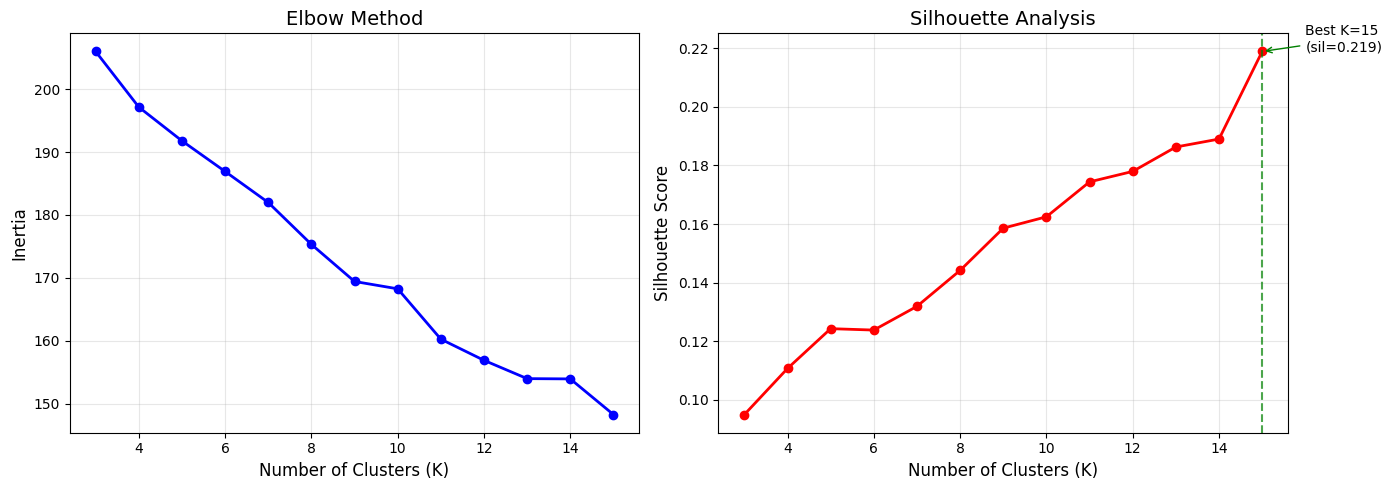

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(K_range, inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14)
ax1.grid(True, alpha=0.3)

ax2.plot(K_range, silhouette_scores_list, 'ro-', linewidth=2)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Analysis', fontsize=14)
ax2.grid(True, alpha=0.3)

best_k = list(K_range)[np.argmax(silhouette_scores_list)]
best_sil = max(silhouette_scores_list)
ax2.axvline(x=best_k, color='green', linestyle='--', alpha=0.7)
ax2.annotate(f'Best K={best_k}\n(sil={best_sil:.3f})',
             xy=(best_k, best_sil), fontsize=10,
             xytext=(best_k+1, best_sil),
             arrowprops=dict(arrowstyle='->', color='green'))

plt.tight_layout()
plt.savefig('elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f'Best K by silhouette score: {best_k}')

Best K by silhouette score: 15


The silhouette score keeps increasing because of the nature of the data, not because K=15 is meaningful. With only ~260 short text descriptions, as you increase K, each cluster becomes smaller and more homogeneous by default, even randomly assigned groups would score higher with more clusters. A silhouette score of 0.20 is still poor, meaning even at K=15 the clusters aren't well-separated.

The elbow method is actually more appropriate here. Looking at the inertia plot, the rate of decrease slows noticeably around K=7-8. Before that, each new cluster captures a lot of new structure. After that, you're getting diminishing returns, each new cluster is just splitting an existing group rather than finding a genuinely new one.

# K-Means Clustering (SKIP)

In [ ]:
k = 10


kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
df_valid['cluster'] = kmeans.fit_predict(tfidf_matrix)

print(f'Silhouette score: {silhouette_score(tfidf_matrix, df_valid["cluster"]):.4f}')
print(f'\nCluster distribution:')
print(df_valid['cluster'].value_counts().sort_index())

Silhouette score: 0.1670

Cluster distribution:
cluster
0    10
1    45
2    24
3    80
4    11
5    37
6    10
7    12
8     8
9    23
Name: count, dtype: int64


In [ ]:
# Inspect each cluster
print('\n' + '=' * 80)
for cluster_id in range(k):
    centroid = kmeans.cluster_centers_[cluster_id]
    top_term_indices = centroid.argsort()[::-1][:10]
    top_terms = [feature_names[i] for i in top_term_indices]
    cluster_acts = df_valid[df_valid['cluster'] == cluster_id]['act_name_en'].values

    print(f'\nCLUSTER {cluster_id}  ({len(cluster_acts)} acts)')
    print(f'  Top terms: {", ".join(top_terms)}')
    print(f'  Sample acts:')
    for act in cluster_acts[:8]:
        print(f'    • {act}')
    print('-' * 80)



CLUSTER 0  (10 acts)
  Top terms: actress, burlesqu, burlesqu actress, vocalist, burlesqu artist, actress vocalist, vocalist burlesqu, dancer, artist, vocalist dancer
  Sample acts:
    • Burlesque Actress
    • Burlesque Actress, Vocalist and Dancer
    • Charming Burlesque Actress
    • Serio-Comic Vocalist and Burlesque Actress
    • Serio-Comedienne and Burlesque Actress
    • Burlesque Actress, Vocalist and Skirt Dancer
    • Protean Actress
    • Burlesque Artistes, Vocalists and Dancers
--------------------------------------------------------------------------------

CLUSTER 1  (45 acts)
  Top terms: vocalist, comic, vocalist dancer, comic vocalist, dancer, serio, serio comic, descript, descript vocalist, extempor
  Sample acts:
    • The Phenomenal Young Violinist and Vocalist
    • Vocalist
    • Soprano Vocalist
    • Comic Vocalist
    • Soprano Vocalist
    • Comic Vocalist and Dancer
    • Vocalists and Dancers
    • Soprano Vocalist
-------------------------------------

# Visualising clusters (pca 2d) (SKIP)

Explained variance: 13.9%


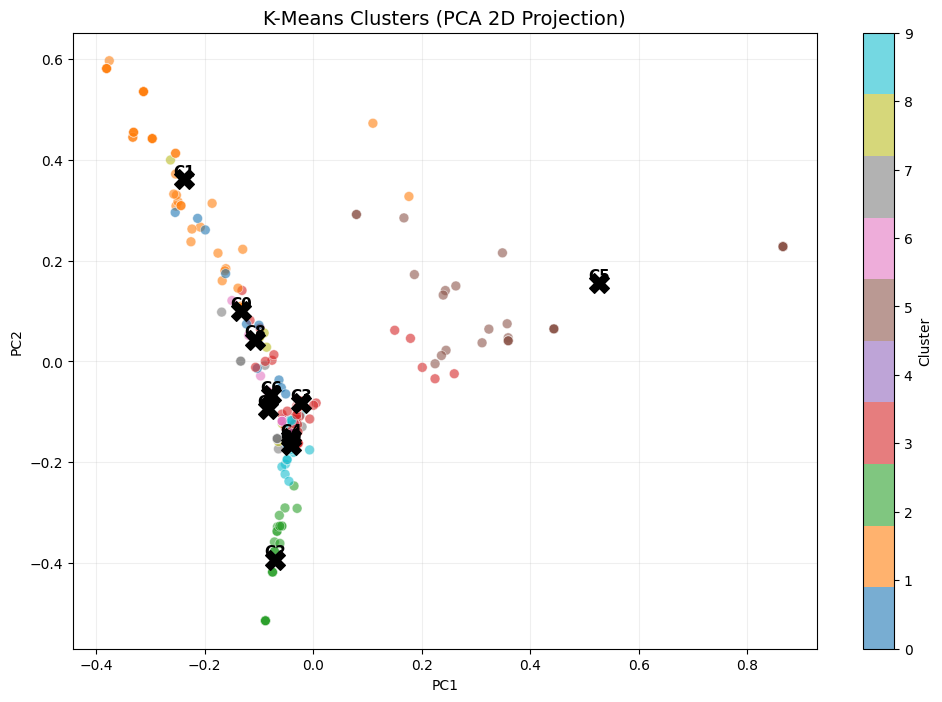

In [ ]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_matrix.toarray())

print(f'Explained variance: {pca.explained_variance_ratio_.sum():.1%}')

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1],
    c=df_valid['cluster'],
    cmap='tab10',
    alpha=0.6, s=50,
    edgecolors='white', linewidth=0.5
)

centroids_2d = pca.transform(kmeans.cluster_centers_)
for i, (cx, cy) in enumerate(centroids_2d):
    ax.scatter(cx, cy, c='black', marker='X', s=200, zorder=5)
    ax.annotate(f'C{i}', (cx, cy), fontsize=11, fontweight='bold',
                ha='center', va='bottom', color='black')

plt.colorbar(scatter, label='Cluster')
ax.set_title('K-Means Clusters (PCA 2D Projection)', fontsize=14)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True, alpha=0.2)
plt.savefig('kmeans_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Hierarchical Clustering (SKIP)

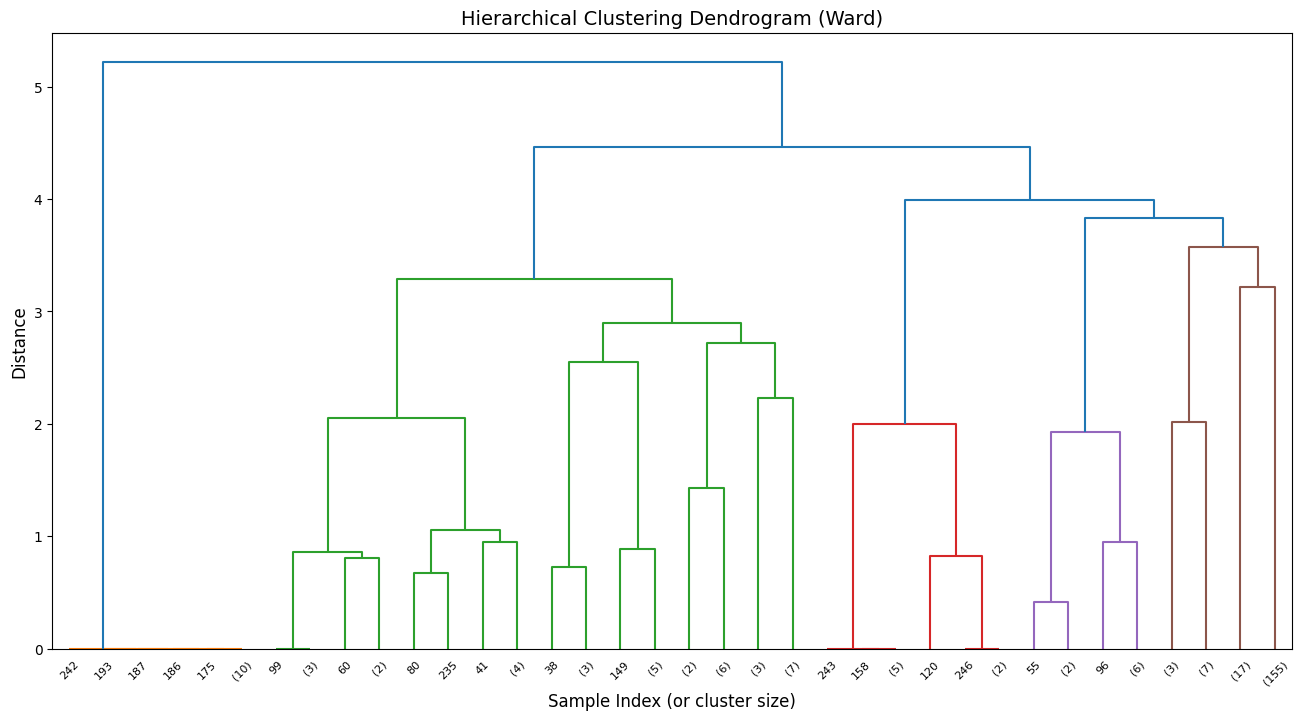

In [ ]:
linkage_matrix = linkage(tfidf_matrix.toarray(), method='ward')

fig, ax = plt.subplots(figsize=(16, 8))
dendrogram(
    linkage_matrix,
    truncate_mode='level',
    p=5,
    ax=ax,
    leaf_font_size=8
)
ax.set_title('Hierarchical Clustering Dendrogram (Ward)', fontsize=14)
ax.set_xlabel('Sample Index (or cluster size)', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
plt.savefig('dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

Comparing silhouette scores

In [ ]:
# Compare silhouette scores
agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
df_valid['cluster_hierarchical'] = agg.fit_predict(tfidf_matrix.toarray())

sil_kmeans = silhouette_score(tfidf_matrix, df_valid['cluster'])
sil_hier = silhouette_score(tfidf_matrix, df_valid['cluster_hierarchical'])

print(f'Silhouette Scores (K={k}):')
print(f'  K-Means:       {sil_kmeans:.4f}')
print(f'  Hierarchical:  {sil_hier:.4f}')
print(f'\n>>> Better method: {"K-Means" if sil_kmeans >= sil_hier else "Hierarchical"}')

Silhouette Scores (K=10):
  K-Means:       0.1670
  Hierarchical:  0.1722

>>> Better method: Hierarchical


#  Cosine Similarity Classification (USE THIS)

Defining categories

In [ ]:
categories = {
    'Comedians': 'comedian comedienne comic burlesque slapstick knockabout funny clown serio-comic comical absurdist humourist low comedy',
    'Singing': 'vocalist singer soprano ballad vocal songster songstress warbler chorus hymn operatic tenor baritone serio alto songs',
    'Dance': 'dancer dancing danseuse ballet skirt dancer boot dancer choreography',
    'Musicians': 'pianist harpist banjo concertina violinist instrumentalist musical instrument fiddle cellist organ soloist',
    'Jugglers': 'juggler juggling',
    'Acrobats': 'acrobat equilibrist tumbler contortionist horizontal bar athletic trapeze',
    'Gymnasts': 'gymnast gymnastics gymnasium horizontal bar',
    'Tightrope walking': 'tightrope walking wire rope',
    'Magic': 'conjurer wizard magician illusionist necromancer second sight transformation quick change telepathy',
    'Motion pictures': 'bioscope motion pictures moving pictures film animated stereoscopic life motion cinematograph screening',
    'Animal trainers': 'animal dog cockatoo performing animals trained',
    'Male impersonators': 'impersonator male impersonator',
    'Stunt performers': 'cycling bicycle novelty stunt cyclist rocket',
    'Imitation': 'mimic imitator delineator impersonation character studies',
}

cat_names = list(categories.keys())

Boosting First Term Importance

In [ ]:
def boost_first_term(text):
    """Repeat the first word to give it more TF-IDF weight."""
    words = text.split()
    if words:
        return words[0] + ' ' + words[0] + ' ' + text
    return text


df_valid['act_boosted'] = df_valid['act_processed'].apply(boost_first_term)

Cosine Similarity for MultiLabel Class

In [ ]:
all_texts = list(df_valid['act_boosted']) + [preprocess(desc) for desc in categories.values()]

tfidf_sim = TfidfVectorizer(
    ngram_range=(1, 2),
    max_features=500,
    stop_words='english'
)
tfidf_all = tfidf_sim.fit_transform(all_texts)

act_vectors = tfidf_all[:len(df_valid)]
cat_vectors = tfidf_all[len(df_valid):]

sim_matrix = cosine_similarity(act_vectors, cat_vectors)

# Assign top 2 categories above threshold
MULTI_THRESHOLD = 0.05

df_valid['primary_category'] = [cat_names[i] for i in sim_matrix.argmax(axis=1)]
df_valid['primary_confidence'] = sim_matrix.max(axis=1)


def get_top_labels(row_idx, max_labels=2):
    scores = sim_matrix[row_idx]
    sorted_idx = scores.argsort()[::-1]
    labels = []
    for j in sorted_idx:
        if scores[j] >= MULTI_THRESHOLD and len(labels) < max_labels:
            labels.append(cat_names[j])
    return labels


df_valid['all_categories'] = [
    ', '.join(get_top_labels(i)) for i in range(len(df_valid))
]

df_valid['num_labels'] = df_valid['all_categories'].apply(lambda x: len(x.split(', ')) if x else 0)
df_valid['needs_fuzzy'] = df_valid['all_categories'] == ''

print('Cosine Similarity (Multi-Label)')
print(f'Acts with at least 1 cosine label: {(~df_valid["needs_fuzzy"]).sum()}')
print(f'Acts needing fuzzy fallback: {df_valid["needs_fuzzy"].sum()}')
print(f'\nLabel count distribution:')
print(df_valid['num_labels'].value_counts().sort_index())

Cosine Similarity (Multi-Label)
Acts with at least 1 cosine label: 137
Acts needing fuzzy fallback: 97

Label count distribution:
num_labels
0    97
1    84
2    53
Name: count, dtype: int64


Fuzzy matching (as a fallback)

In [ ]:
category_keywords = {}
for cat, desc in categories.items():
    category_keywords[cat] = desc.split()


def fuzzy_classify(act_name):
    """Match act description against each category's keywords using fuzzy matching."""
    act_lower = act_name.lower()
    results = {}

    for cat, keywords in category_keywords.items():
        best_score = 0
        for keyword in keywords:
            score = fuzz.partial_ratio(keyword, act_lower)
            if score > best_score:
                best_score = score
        results[cat] = best_score

    return results


In [ ]:
FUZZY_THRESHOLD = 60

fuzzy_mask = df_valid['needs_fuzzy']
print(f'\n=== STEP 2: Fuzzy Matching on {fuzzy_mask.sum()} acts ===')

for idx in df_valid[fuzzy_mask].index:
    # Use the cleaned description for fuzzy matching (less noise)
    scores = fuzzy_classify(df_valid.at[idx, 'act_cleaned'])

    sorted_cats = sorted(scores.items(), key=lambda x: -x[1])
    matched_cats = [cat for cat, score in sorted_cats if score >= FUZZY_THRESHOLD][:2]

    if matched_cats:
        df_valid.at[idx, 'all_categories'] = ', '.join(matched_cats)
        df_valid.at[idx, 'primary_category'] = matched_cats[0]
        df_valid.at[idx, 'num_labels'] = len(matched_cats)
    else:
        # No match above threshold — assign best guess
        best_cat = max(scores, key=scores.get)
        df_valid.at[idx, 'all_categories'] = best_cat
        df_valid.at[idx, 'primary_category'] = best_cat
        df_valid.at[idx, 'num_labels'] = 1




=== STEP 2: Fuzzy Matching on 97 acts ===


Results Summary

In [ ]:
print(f'\nTotal acts classified: {len(df_valid)}')
print(f'Acts with multiple labels: {(df_valid["num_labels"] > 1).sum()} ({(df_valid["num_labels"] > 1).mean():.1%})')
print(f'Acts with single label: {(df_valid["num_labels"] == 1).sum()}')
print(f'Average labels per act: {df_valid["num_labels"].mean():.2f}')

print(f'\nPrimary category distribution:')
print(df_valid['primary_category'].value_counts())

all_cat_counts = {}
for cats in df_valid['all_categories']:
    for cat in cats.split(', '):
        cat = cat.strip()
        all_cat_counts[cat] = all_cat_counts.get(cat, 0) + 1

print(f'\nTotal label appearances (including multi-labels):')
for cat, count in sorted(all_cat_counts.items(), key=lambda x: -x[1]):
    primary_count = (df_valid['primary_category'] == cat).sum()
    secondary_count = count - primary_count
    print(f'  {cat:25s}  primary: {primary_count:3d}  |  secondary: {secondary_count:3d}  |  total: {count:3d}')


Total acts classified: 234
Acts with multiple labels: 137 (58.5%)
Acts with single label: 97
Average labels per act: 1.59

Primary category distribution:
primary_category
Comedians             72
Singing               40
Dance                 29
Magic                 12
Imitation             12
Musicians             12
Acrobats              11
Motion pictures       11
Animal trainers        9
Stunt performers       8
Tightrope walking      8
Male impersonators     6
Jugglers               3
Gymnasts               1
Name: count, dtype: int64

Total label appearances (including multi-labels):
  Comedians                  primary:  72  |  secondary:  19  |  total:  91
  Singing                    primary:  40  |  secondary:  34  |  total:  74
  Dance                      primary:  29  |  secondary:  12  |  total:  41
  Musicians                  primary:  12  |  secondary:  12  |  total:  24
  Acrobats                   primary:  11  |  secondary:  10  |  total:  21
  Imitation          

Classifications Samples

In [ ]:
# multi label classifications

multi = df_valid[df_valid['num_labels'] > 1].sort_values('num_labels', ascending=False)
print(f'Acts with multiple labels ({len(multi)} total):\n')
for _, row in multi.head(25).iterrows():
    print(f'  [{row["num_labels"]} labels] {row["act_cleaned"][:80]}')
    print(f'           → {row["all_categories"]}')
    print()

print('\n=== SINGLE-LABEL EXAMPLES ===\n')
single = df_valid[df_valid['num_labels'] == 1]
for cat in sorted(single['primary_category'].unique()):
    acts = single[single['primary_category'] == cat]
    print(f'{cat} ({len(acts)} single-label acts):')
    for _, row in acts.head(3).iterrows():
        print(f'  • {row["act_cleaned"][:80]}')
    print()


Acts with multiple labels (137 total):

  [2 labels] Continental Wonders, for Six Nights only
           → Magic, Comedians

  [2 labels] In Selestions from their Repertoire of Old Folk Songs and Comedy Duets
           → Comedians, Singing

  [2 labels] Popular Comedian, Dry and Droll
           → Comedians, Acrobats

  [2 labels] Dainty Vosalist and Dancar
           → Singing, Dance

  [2 labels] England's Smallest Dapper Comedian
           → Comedians, Dance

  [2 labels] High-class Comedy Act
           → Comedians, Magic

  [2 labels] PRINCE CHARMING
           → Motion pictures, Singing

  [2 labels] Showing a Sarise al Noval axé interesting Pistaros
           → Comedians, Singing

  [2 labels] In Startingly Natural Representation of the many Diverting and Comic Incidents o
           → Animal trainers, Comedians

  [2 labels] And FLORRIE
           → Comedians, Tightrope walking

  [2 labels] ACTOR-VOCALIST
           → Singing, Musicians

  [2 labels] And NELLIE
           →

# Similarity Heatmap

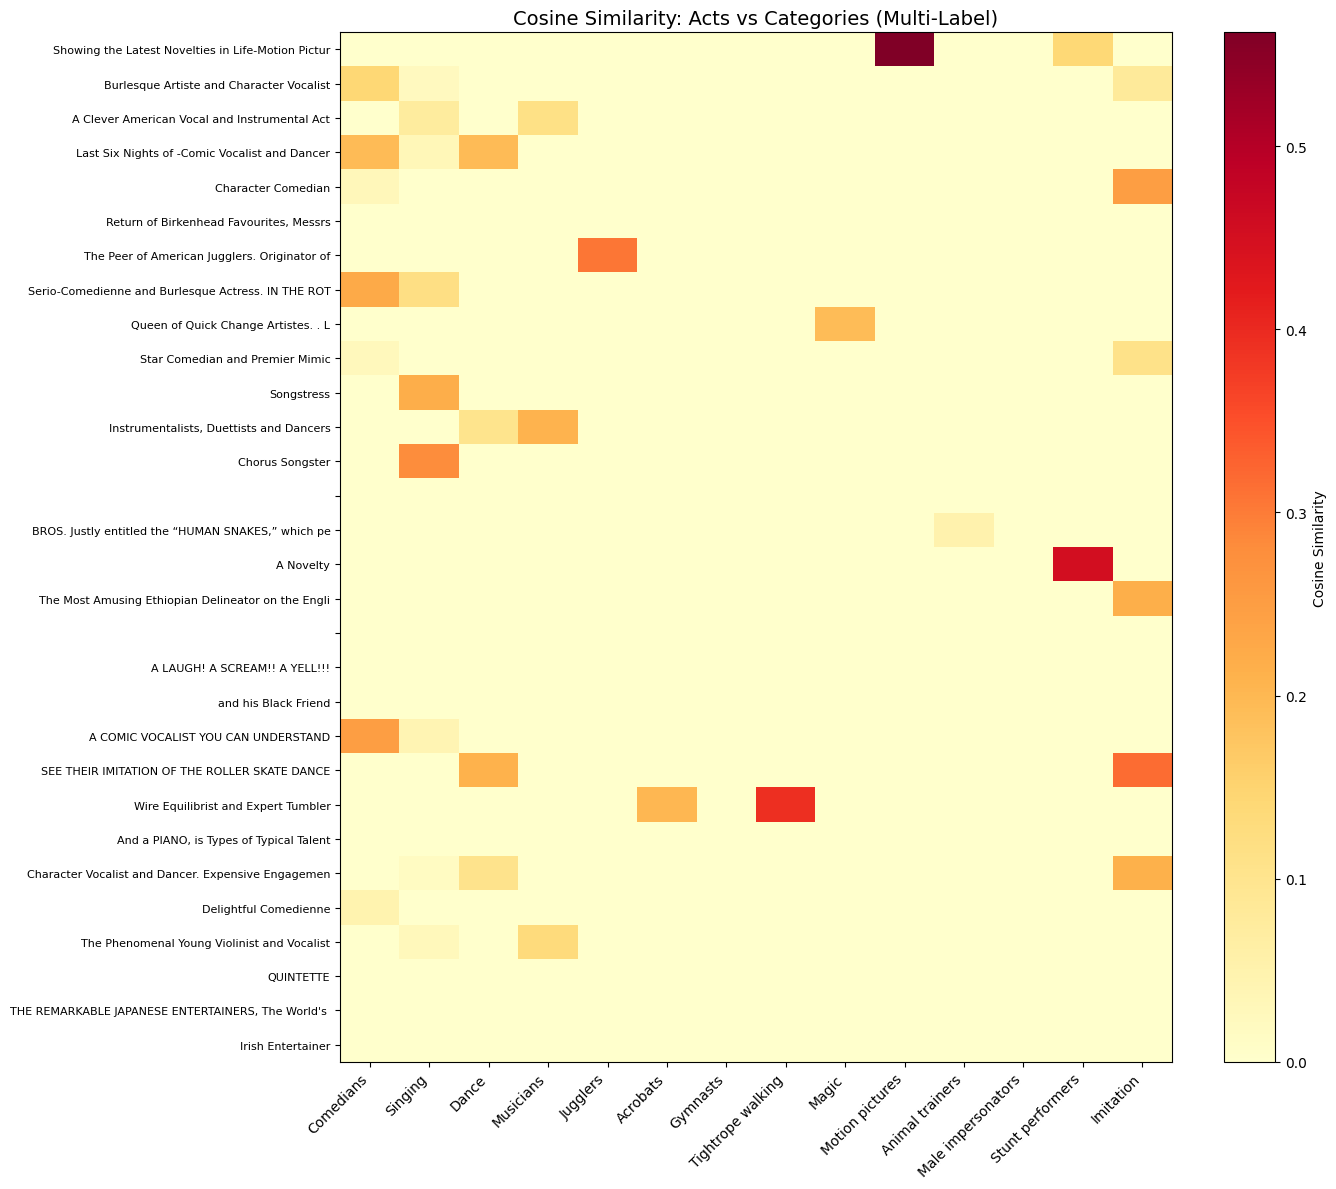

In [ ]:
sample_idx = df_valid.sample(30, random_state=42).index
sample_sim = sim_matrix[sample_idx]
sample_labels = df_valid.loc[sample_idx, 'act_cleaned'].values

fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(sample_sim, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(cat_names)))
ax.set_xticklabels(cat_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(len(sample_labels)))
ax.set_yticklabels([s[:50] for s in sample_labels], fontsize=8)
ax.set_title('Cosine Similarity: Acts vs Categories (Multi-Label)', fontsize=14)
plt.colorbar(im, label='Cosine Similarity')
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Multi Label Distribution Chart

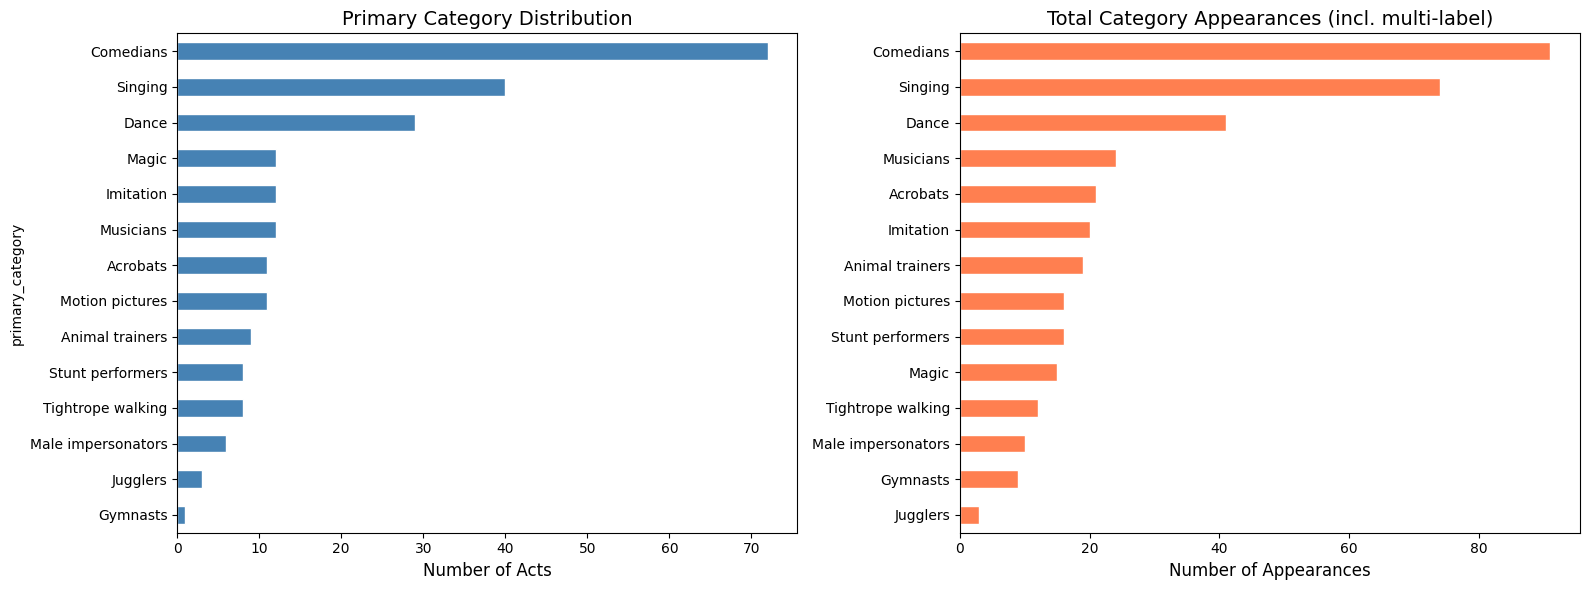

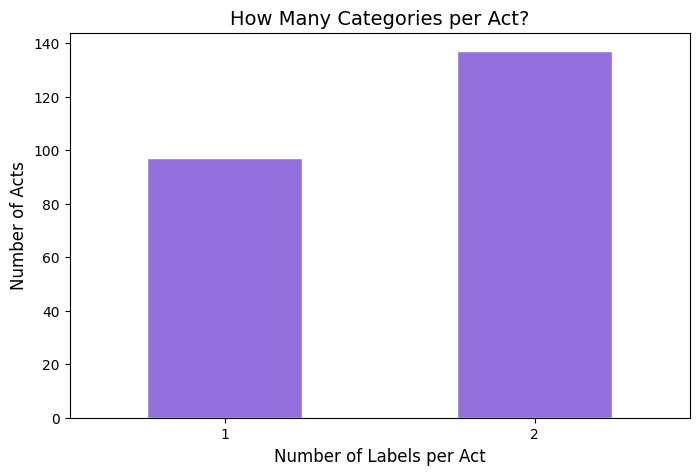

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

df_valid['primary_category'].value_counts().plot(
    kind='barh', ax=ax1, color='steelblue', edgecolor='white'
)
ax1.set_xlabel('Number of Acts', fontsize=12)
ax1.set_title('Primary Category Distribution', fontsize=14)
ax1.invert_yaxis()

cat_series = pd.Series(all_cat_counts).sort_values(ascending=True)
cat_series.plot(kind='barh', ax=ax2, color='coral', edgecolor='white')
ax2.set_xlabel('Number of Appearances', fontsize=12)
ax2.set_title('Total Category Appearances (incl. multi-label)', fontsize=14)

plt.tight_layout()
plt.savefig('category_distribution_multilabel.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(8, 5))
df_valid['num_labels'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='mediumpurple', edgecolor='white'
)
ax.set_xlabel('Number of Labels per Act', fontsize=12)
ax.set_ylabel('Number of Acts', fontsize=12)
ax.set_title('How Many Categories per Act?', fontsize=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.savefig('label_count_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


# Export Results

In [ ]:
df_output = df.copy()
df_output['primary_category'] = 'Unknown'
df_output['all_categories'] = 'Unknown'
df_output['num_labels'] = 0

valid_indices = df[~empty_mask].index
for i, orig_idx in enumerate(valid_indices):
    df_output.at[orig_idx, 'primary_category'] = df_valid.at[i, 'primary_category']
    df_output.at[orig_idx, 'all_categories'] = df_valid.at[i, 'all_categories']
    df_output.at[orig_idx, 'num_labels'] = df_valid.at[i, 'num_labels']

output_path = 'hackathon_2_classified.csv'
df_output.to_csv(output_path, index=False)
print(f'Saved to {output_path}')
print(f'\nFinal distribution (primary):')
print(df_output['primary_category'].value_counts())
print(f'\nTotal: {len(df_output)}')

print('\nSample rows:')
cols = ['act_name', 'act_description', 'primary_category', 'all_categories', 'num_labels']
print(df_output[cols].sample(20, random_state=42).to_string())




Saved to hackathon_2_classified.csv

Final distribution (primary):
primary_category
Comedians             72
Singing               40
Dance                 29
Magic                 12
Imitation             12
Musicians             12
Acrobats              11
Motion pictures       11
Animal trainers        9
Stunt performers       8
Tightrope walking      8
Male impersonators     6
Jugglers               3
Gymnasts               1
Unknown                1
Name: count, dtype: int64

Total: 235

Sample rows:
                   act_name                                                                                                                                         act_description   primary_category                     all_categories  num_labels
69   BROWN'S ROYAL BIOSCOPE                                                                                                   Showing the Latest Novelties in Life-Motion Pictures.    Motion pictures  Motion pictures, Stunt performers          

# Validation against library metadata

data read and category mapping

In [ ]:
library_df = pd.read_csv('library_metadata.csv', encoding='utf-8-sig')

print(f'Library metadata: {len(library_df)} posters')
print(f'Your classifications: {len(df_output)} acts')

library_to_ours = {
    'Comedians': 'Comedians',
    'Singing': 'Singing',
    'Dance': 'Dance',
    'Musicians': 'Musicians',
    'Jugglers': 'Jugglers',
    'Acrobats': 'Acrobats',
    'Gymnasts': 'Gymnasts',
    'Tightrope walking': 'Tightrope walking',
    'Magic': 'Magic',
    'Motion pictures': 'Motion pictures',
    'Animal trainers': 'Animal trainers',
    'Male impersonators': 'Male impersonators',
    'Imitation': 'Imitation',
    'Stunt performers': 'Stunt performers',
}


Library metadata: 30 posters
Your classifications: 235 acts


Map source_file to library accession number


In [ ]:

df_output['poster_id'] = df_output['source_file'].apply(
    lambda x: x.replace('NFA', '').replace('-', '.').replace('.jpg', '')
)

results = []

for _, poster in library_df.iterrows():
    accession = poster['Accession Number']

    raw_subjects = str(poster['Subject']).split(';')
    library_labels = set()
    for s in raw_subjects:
        s = s.strip().rstrip(';').strip()
        if s and s in library_to_ours:
            library_labels.add(library_to_ours[s])

    # Match using poster_id derived from source_file
    poster_acts = df_output[df_output['poster_id'] == accession]

    if len(poster_acts) == 0:
        continue  # This poster isn't in our dataset

    predicted_labels = set()
    for cats in poster_acts['all_categories']:
        if isinstance(cats, str) and cats != 'Unknown':
            for cat in cats.split(', '):
                predicted_labels.add(cat.strip())

    results.append({
        'accession': accession,
        'library_labels': library_labels,
        'predicted_labels': predicted_labels,
        'num_acts': len(poster_acts),
    })

print(f'Posters matched for validation: {len(results)} / {len(library_df)}')

Posters matched for validation: 24 / 30


per category metrics

In [ ]:
all_categories_val = sorted(set(
    list(library_to_ours.values()) +
    [cat for r in results for cat in r['predicted_labels']]
))

tp = {cat: 0 for cat in all_categories_val}
fp = {cat: 0 for cat in all_categories_val}
fn = {cat: 0 for cat in all_categories_val}

for r in results:
    for cat in all_categories_val:
        in_library = cat in r['library_labels']
        in_predicted = cat in r['predicted_labels']

        if in_library and in_predicted:
            tp[cat] += 1
        elif in_predicted and not in_library:
            fp[cat] += 1
        elif in_library and not in_predicted:
            fn[cat] += 1


per category validation

In [ ]:
print(f'{"Category":25s}  {"F1":>10s} {"Precision":>10s}  {"Recall":>10s} {"TP":>4s}  {"FP":>4s}  {"FN":>4s}')
print('-' * 85)

f1_scores = {}
for cat in all_categories_val:
    precision = tp[cat] / (tp[cat] + fp[cat]) if (tp[cat] + fp[cat]) > 0 else 0
    recall = tp[cat] / (tp[cat] + fn[cat]) if (tp[cat] + fn[cat]) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    f1_scores[cat] = f1

for cat in sorted(f1_scores, key=f1_scores.get, reverse=True):
    precision = tp[cat] / (tp[cat] + fp[cat]) if (tp[cat] + fp[cat]) > 0 else 0
    recall = tp[cat] / (tp[cat] + fn[cat]) if (tp[cat] + fn[cat]) > 0 else 0
    print(f'{cat:25s}  {precision:10.2%}  {recall:10.2%}  {f1_scores[cat]:10.2%}  {tp[cat]:4d}  {fp[cat]:4d}  {fn[cat]:4d}')

Category                           F1  Precision      Recall   TP    FP    FN
-------------------------------------------------------------------------------------
Comedians                     100.00%     100.00%     100.00%    24     0     0
Singing                        90.91%      90.91%      90.91%    20     2     2
Dance                          71.43%      93.75%      81.08%    15     6     1
Jugglers                       66.67%     100.00%      80.00%     2     1     0
Motion pictures                66.67%     100.00%      80.00%     8     4     0
Musicians                      57.14%      88.89%      69.57%     8     6     1
Animal trainers                30.77%     100.00%      47.06%     4     9     0
Male impersonators             28.57%     100.00%      44.44%     2     5     0
Acrobats                       20.00%     100.00%      33.33%     3    12     0
Gymnasts                       14.29%     100.00%      25.00%     1     6     0
Tightrope walking              10.00

weighted metrics

In [ ]:
# Weighted-averaged
total_support = sum(tp[cat] + fn[cat] for cat in all_categories_val)
weighted_f1 = sum(
    f1_scores[cat] * (tp[cat] + fn[cat]) / total_support
    for cat in all_categories_val
    if (tp[cat] + fn[cat]) > 0
)
weighted_precision = sum(
    (tp[cat] / (tp[cat] + fp[cat]) if (tp[cat] + fp[cat]) > 0 else 0) * (tp[cat] + fn[cat]) / total_support
    for cat in all_categories_val
    if (tp[cat] + fn[cat]) > 0
)
weighted_recall = sum(
    (tp[cat] / (tp[cat] + fn[cat]) if (tp[cat] + fn[cat]) > 0 else 0) * (tp[cat] + fn[cat]) / total_support
    for cat in all_categories_val
    if (tp[cat] + fn[cat]) > 0
)

print('-' * 85)
print(f'{"OVERALL (weighted-avg)":25s}  {weighted_f1:10.2%} {weighted_precision:10.2%}  {weighted_recall:10.2%}' )

-------------------------------------------------------------------------------------
OVERALL (weighted-avg)         79.89%     73.82%      95.79%


In [ ]:
all_categories_val = sorted(set(
    list(library_to_ours.values()) +
    [cat for r in results for cat in r['predicted_labels']]
))

tp = {cat: 0 for cat in all_categories_val}
fp = {cat: 0 for cat in all_categories_val}
fn = {cat: 0 for cat in all_categories_val}

for r in results:
    for cat in all_categories_val:
        in_library = cat in r['library_labels']
        in_predicted = cat in r['predicted_labels']

        if in_library and in_predicted:
            tp[cat] += 1
        elif in_predicted and not in_library:
            fp[cat] += 1
        elif in_library and not in_predicted:
            fn[cat] += 1

Validation against library metadata

In [ ]:
for r in results:
    match = r['library_labels'] == r['predicted_labels']
    overlap = r['library_labels'] & r['predicted_labels']
    missed = r['library_labels'] - r['predicted_labels']
    extra = r['predicted_labels'] - r['library_labels']

    status = 'EXACT MATCH' if match else 'PARTIAL' if overlap else 'MISMATCH'

    print(f'{r["accession"]} ({r["num_acts"]} acts) — {status}')
    print(f'  Library:   {", ".join(sorted(r["library_labels"])) or "none"}')
    print(f'  Predicted: {", ".join(sorted(r["predicted_labels"])) or "none"}')
    if missed:
        print(f'  MISSED:    {", ".join(sorted(missed))}')
    if extra:
        print(f'  EXTRA:     {", ".join(sorted(extra))}')
    print()

178R12.16 (9 acts) — PARTIAL
  Library:   Animal trainers, Comedians, Dance, Gymnasts, Singing
  Predicted: Acrobats, Animal trainers, Comedians, Dance, Gymnasts, Magic, Motion pictures, Musicians, Singing
  EXTRA:     Acrobats, Magic, Motion pictures, Musicians

178R12.18 (10 acts) — PARTIAL
  Library:   Comedians, Musicians, Singing
  Predicted: Comedians, Dance, Imitation, Magic, Musicians, Singing, Tightrope walking
  EXTRA:     Dance, Imitation, Magic, Tightrope walking

178R12.26 (10 acts) — PARTIAL
  Library:   Comedians, Dance, Singing
  Predicted: Acrobats, Comedians, Dance, Imitation, Musicians, Singing, Stunt performers, Tightrope walking
  EXTRA:     Acrobats, Imitation, Musicians, Stunt performers, Tightrope walking

178R12.30 (9 acts) — PARTIAL
  Library:   Comedians, Dance, Imitation
  Predicted: Animal trainers, Comedians, Dance, Imitation, Singing
  EXTRA:     Animal trainers, Singing

178R12.35 (10 acts) — PARTIAL
  Library:   Comedians, Dance, Singing
  Predicted: Ac

Validation Chart

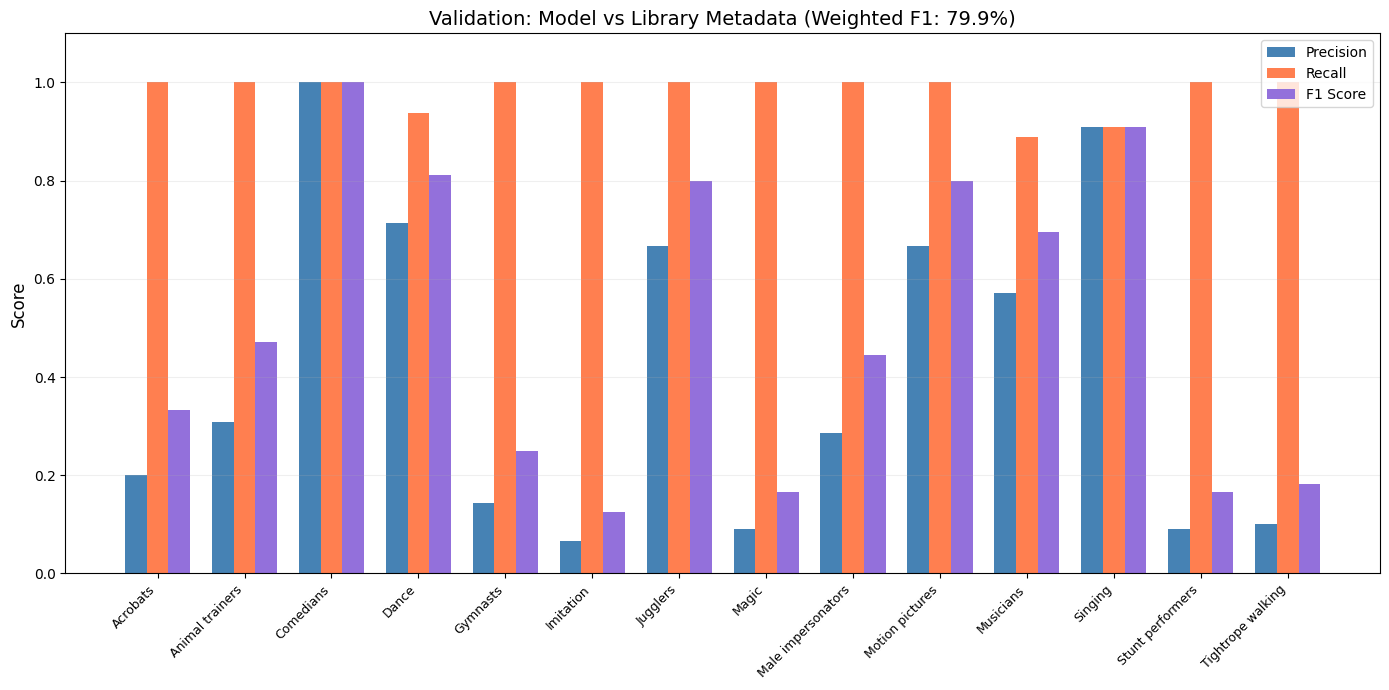

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
cats = [c for c in f1_scores.keys() if (tp[c] + fp[c] + fn[c]) > 0]
f1_vals = [f1_scores[c] for c in cats]
prec_vals = [tp[c] / (tp[c] + fp[c]) if (tp[c] + fp[c]) > 0 else 0 for c in cats]
rec_vals = [tp[c] / (tp[c] + fn[c]) if (tp[c] + fn[c]) > 0 else 0 for c in cats]

x = np.arange(len(cats))
width = 0.25

ax.bar(x - width, prec_vals, width, label='Precision', color='steelblue')
ax.bar(x, rec_vals, width, label='Recall', color='coral')
ax.bar(x + width, f1_vals, width, label='F1 Score', color='mediumpurple')

ax.set_xticks(x)
ax.set_xticklabels(cats, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(f'Validation: Model vs Library Metadata (Weighted F1: {weighted_f1:.1%})', fontsize=14)
ax.legend()
ax.set_ylim(0, 1.1)
ax.grid(True, alpha=0.2, axis='y')

plt.tight_layout()
plt.savefig('validation_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print(f'Weighted F1 Score: {weighted_f1:.1%}')

Weighted F1 Score: 79.9%


In [ ]:
library_lookup = {}
for _, poster in library_df.iterrows():
    accession = poster['Accession Number']
    raw_subjects = str(poster['Subject']).split(';')
    labels = set()
    for s in raw_subjects:
        s = s.strip().rstrip(';').strip()
        if s and s in library_to_ours:
            labels.add(library_to_ours[s])
    library_lookup[accession] = ', '.join(sorted(labels))

df_output['library_categories'] = df_output['poster_id'].map(library_lookup).fillna('')
df_output['classification_method'] = 'cosine'

valid_indices = df[~empty_mask].index
for i, orig_idx in enumerate(valid_indices):
    if df_valid.at[i, 'needs_fuzzy']:
        df_output.at[orig_idx, 'classification_method'] = 'fuzzy'

df_output.loc[df_output['primary_category'] == 'Unknown', 'classification_method'] = 'empty'

df_output.to_csv('hackathon_qwen_classified.csv', index=False)

print('Updated CSV with library_categories and classification_method columns')
print(f'\nMethod breakdown:')
print(df_output['classification_method'].value_counts())
print(f'\nSample rows:')
cols = ['act_name', 'act_description', 'primary_category', 'all_categories', 'library_categories', 'classification_method']
print(df_output[cols].head(15).to_string())

Updated CSV with library_categories and classification_method columns

Method breakdown:
classification_method
cosine    137
fuzzy      97
empty       1
Name: count, dtype: int64

Sample rows:
               act_name                                                                                                                                                                                              act_description primary_category        all_categories           library_categories classification_method
0      Mr. ARTHUR LLOYD  THE GREAT VOCAL COMEDIAN.\nThe name of Arthur Lloyd is known in every English-speaking country\nin the world; he is the Author of upwards of 1,000 Humorous Songs and\nthe Great Irish Drama, "Ballyvogan."          Singing               Singing    Comedians, Dance, Singing                cosine
1                HOLMES                                                                                                                                           The Gre